In [1]:
import matplotlib.pyplot as plt 

from UIUCProcessor import UIUCProcessor

from Observer_Manager import ObserverManager
from BEMT_Acoustic_Job import Job

In [6]:
"""GET UIUC DATA"""
propeller_name = "14x12E"

processor = UIUCProcessor('./Experimental Data/uiuc')
filename = processor.find_uiuc_data(propeller_name)
uiuc_data = processor.load_uiuc_data(filename)

14x12


In [7]:
"""CREATE ANALYSIS OBJECT AND RUN BEMT"""
r_observer = []
observer_manager = ObserverManager.from_positions(r_observer)

v_inf = 0 
revolutions = 6 #revolutions to simulate

Ct = []
Cp = []
for RPM in uiuc_data['data']['rpm']:
    analysis = Job(propeller_name=propeller_name, RPM=RPM, v_inf=v_inf, revolutions=revolutions, observer_manager=observer_manager)
    analysis.run_BEMT()
    Ct.append(analysis.Ct), Cp.append(analysis.Cp)

Running BEMT for propeller 14X12E at 1496.0 RPM and 0 m/s...
0.7789960073445044 0.06397222374995461
Running BEMT for propeller 14X12E at 1636.0 RPM and 0 m/s...
0.9393082436581447 0.06450018169911684
Running BEMT for propeller 14X12E at 1741.0 RPM and 0 m/s...
1.0694263809047158 0.06484444146567145
Running BEMT for propeller 14X12E at 1904.0 RPM and 0 m/s...
1.2892109865124446 0.0653596191110637
Running BEMT for propeller 14X12E at 2036.0 RPM and 0 m/s...
1.4876709036148759 0.06595849301533442
Running BEMT for propeller 14X12E at 2172.0 RPM and 0 m/s...
1.7194366900568554 0.0669862939192285
Running BEMT for propeller 14X12E at 2302.0 RPM and 0 m/s...
2.007142722284149 0.06961246608861321
Running BEMT for propeller 14X12E at 2444.0 RPM and 0 m/s...
2.3551663677998604 0.0724667176594058
Running BEMT for propeller 14X12E at 2574.0 RPM and 0 m/s...
2.6570720395662466 0.07370647592204943
Running BEMT for propeller 14X12E at 2706.0 RPM and 0 m/s...
2.98234998204114 0.07485527761984631
Runnin

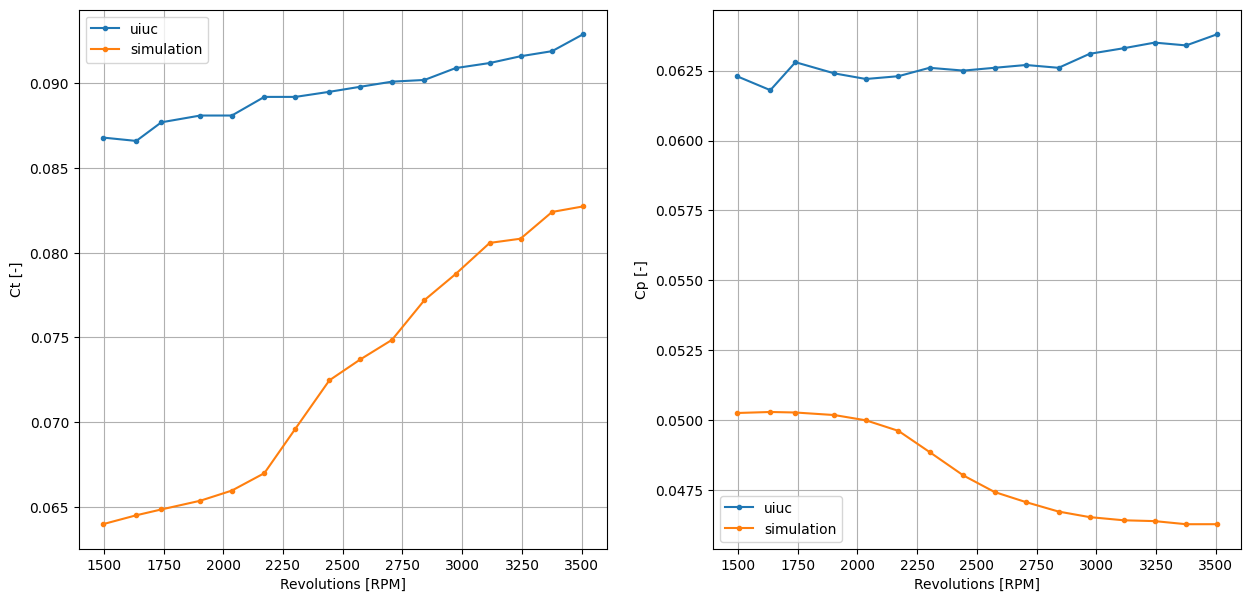

In [8]:
"""COMPARE UIUC AND BEMT"""
%matplotlib inline
fig, axs = plt.subplots(1,2)
fig.set_figheight(7)
fig.set_figwidth(15)
fontsize=10
labelsize=10

axs[0].plot(uiuc_data['data']['rpm'], uiuc_data['data']['ct'], marker='.', label='uiuc')
axs[0].plot(uiuc_data['data']['rpm'], Ct, marker='.', label='simulation')
axs[0].set_xlabel('Revolutions [RPM]', fontsize=fontsize)
axs[0].set_ylabel('Ct [-]', fontsize=fontsize)
axs[0].grid(True)
axs[0].legend()

axs[1].plot(uiuc_data['data']['rpm'], uiuc_data['data']['cp'], marker='.', label='uiuc')
axs[1].plot(uiuc_data['data']['rpm'], Cp, marker='.', label='simulation')
axs[1].set_xlabel('Revolutions [RPM]', fontsize=fontsize)
axs[1].set_ylabel('Cp [-]', fontsize=fontsize)
axs[1].grid(True)
axs[1].legend()